In [1]:
# Imports
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import json

In [2]:
current_directory = Path.cwd().parent
discharge_directory = Path.joinpath(current_directory, "Data Start Point")

compiled_file_name = Path.joinpath(discharge_directory, "compiled_output.csv")
output_file_name = Path.joinpath(discharge_directory, "final_cleaned_compiled.csv")
points_of_interest_file_name = Path.joinpath(discharge_directory, "points_of_interest.json")

def create_csv_output_file(override=False, csv_data=None):
    if override and Path.exists(output_file_name):
        Path.unlink(output_file_name)
    
    if csv_data is not None:
        csv_data.to_csv(output_file_name, mode='a', header=not Path.exists(output_file_name), index=False)

In [3]:
combined_df = pd.read_csv(compiled_file_name)
print(combined_df.shape)
print(combined_df.head())

(11362394, 8)
   Translated Time  Translated Time (minutes)  \
0            0.000                   0.000000   
1            0.942                   0.000016   
2            1.880                   0.000031   
3            2.819                   0.000047   
4            3.757                   0.000063   

   ADS Reading 1 (Smoothed and Offset)  Calibrated Current 1  \
0                              32755.0             -0.031158   
1                              32746.0             -0.053594   
2                              32737.0             -0.076032   
3                              32755.0             -0.031158   
4                              32737.0             -0.076032   

   ADS Reading 2 (Smoothed and Offset)  Calibrated Current 2  \
0                              32730.0             -0.093485   
1                              32722.5             -0.112186   
2                              32722.0             -0.113433   
3                              32722.0            

In [73]:
CIRCUIT_CLOSE_VOLTAGE_DROP_THRESHOLD = 0.3
prev_found_time = -999

# Tuple of time (min) and voltage
last_stable_voltages_before_close = {"index": [], "time": [], "voltage": []}
for index in range(20, len(combined_df) - 100000):
    if index % 10000 == 0:
        print(f"Processing index {index}/{len(combined_df)}", end="\r")   
    # Voltage drop + time gap > 1 min + voltage drop > threshold
    if combined_df["Translated Time (minutes)"].iloc[index] - prev_found_time > 1:
        curr = combined_df['Calibrated Voltage'].iloc[index]    # Current point
        following = combined_df['Calibrated Voltage'].iloc[index:index+500].mean() # Avg of next few point to confirm it is the edge
        next = combined_df['Calibrated Voltage'].iloc[index+90000:index+100000].max() # Ensure that drop is not due to noise
        
        if curr - following > 0.01 and curr > next + CIRCUIT_CLOSE_VOLTAGE_DROP_THRESHOLD:
            print(f"Found potential circuit close at index {index} with voltage drop from {curr:.2f} V to {next:.2f} V at time {combined_df['Translated Time (minutes)'].iloc[index]:.2f} min.")
            # Take a few step back to get last stable voltage before circuit close
            last_stable_voltages_before_close['index'].append(index)
            last_stable_voltages_before_close['time'].append(combined_df["Translated Time (minutes)"].iloc[index-20:index].mean())
            last_stable_voltages_before_close['voltage'].append(combined_df['Calibrated Voltage'].iloc[index-20:index].mean())
            prev_found_time = combined_df["Translated Time (minutes)"].iloc[index]
    
print("Found", len(last_stable_voltages_before_close['time']), "points\t\t\t\t\t\t\t\t\t\t\t\t\t\t\t")
is_close_filtered = False

Found potential circuit close at index 3863 with voltage drop from 52.42 V to 49.80 V at time 0.06 min.
Found potential circuit close at index 538081 with voltage drop from 50.75 V to 50.24 V at time 8.65 min.
Found potential circuit close at index 1492630 with voltage drop from 52.83 V to 50.37 V at time 24.11 min.
Found potential circuit close at index 2671045 with voltage drop from 52.64 V to 50.50 V at time 43.67 min.
Found potential circuit close at index 3212971 with voltage drop from 50.50 V to 17.04 V at time 52.38 min.
Found potential circuit close at index 4239708 with voltage drop from 52.33 V to 50.40 V at time 68.95 min.
Found potential circuit close at index 5523407 with voltage drop from 52.22 V to 50.26 V at time 89.75 min.
Found potential circuit close at index 6945422 with voltage drop from 52.19 V to 50.09 V at time 112.76 min.
Found potential circuit close at index 8190944 with voltage drop from 51.90 V to 49.85 V at time 132.94 min.
Found potential circuit close at

In [74]:
print(last_stable_voltages_before_close['time'])
print(last_stable_voltages_before_close['voltage'])
to_drop = []
for index in range(1, len(last_stable_voltages_before_close['time'])):
    if last_stable_voltages_before_close['voltage'][index] > last_stable_voltages_before_close['voltage'][index-1]:
        curr_voltage = last_stable_voltages_before_close['voltage'][index]
        for i in range(index):
            if last_stable_voltages_before_close['voltage'][i] < curr_voltage:
                to_drop.append(i)

print("Dropping indices", to_drop)
last_stable_voltages_before_close['index'] = [index for i, index in enumerate(last_stable_voltages_before_close['index']) if i not in to_drop]
last_stable_voltages_before_close['time'] = [time for i, time in enumerate(last_stable_voltages_before_close['time']) if i not in to_drop]
last_stable_voltages_before_close['voltage'] = [voltage for i, voltage in enumerate(last_stable_voltages_before_close['voltage']) if i not in to_drop]
print("After dropping, found", len(last_stable_voltages_before_close['time']), "points")

[np.float64(0.060432800833333335), np.float64(8.652549938333333), np.float64(24.10656765166666), np.float64(43.66643954999999), np.float64(52.37856306416667), np.float64(68.95378443000001), np.float64(89.75069793250005), np.float64(112.76274617000001), np.float64(132.93641707333336), np.float64(153.0244092233334), np.float64(159.8179266016667), np.float64(161.20738906666674), np.float64(162.23309764750002), np.float64(176.83088389583327), np.float64(177.84422702749995), np.float64(179.15911596749993), np.float64(180.23560832749993), np.float64(181.70647124916655)]
[np.float64(52.42040924696727), np.float64(50.750649393453884), np.float64(52.82729045548181), np.float64(52.635896910048075), np.float64(50.49827054245823), np.float64(52.32712657358663), np.float64(52.22109370565346), np.float64(52.188561959258415), np.float64(51.905010757610434), np.float64(51.23853183794919), np.float64(48.49911503776608), np.float64(48.15223474479286), np.float64(47.65221149004349), np.float64(25.2777763

In [ ]:
CIRCUIT_OPEN_VOLTAGE_JUMP_THRESHOLD = 0.5
prev_found_time = -999
# Tuple of time (min) and voltage
last_stable_voltages_before_open = {"index": [], "time": [], "voltage": []}

for index in range(20, len(combined_df)-500): 
    if index % 1000 == 0:
        print(f"Processing index {index}/{len(combined_df)}", end="\r")   
    # Voltage drop + time gap > 1 min + voltage drop > threshold
    if combined_df["Translated Time (minutes)"].iloc[index] - prev_found_time > 1:
        curr = combined_df['Calibrated Voltage'].iloc[index]
        next = combined_df['Calibrated Voltage'].iloc[index+90000:index+100000].min()
        following = combined_df['Calibrated Voltage'].iloc[index+1:index+500].mean() # Avg of next few point to confirm it is the edge
        
        if following - curr > 0.1 and next - curr > CIRCUIT_OPEN_VOLTAGE_JUMP_THRESHOLD:
            print(f"Found potential circuit open at index {index} with voltage jump from {curr:.2f} V to {next:.2f} V at time {combined_df['Translated Time (minutes)'].iloc[index]:.2f} min.")
            # Take a few step back to get last stable voltage before circuit open
            last_stable_voltages_before_open['index'].append(index)
            last_stable_voltages_before_open['time'].append(combined_df["Translated Time (minutes)"].iloc[index-20:index].mean())
            last_stable_voltages_before_open['voltage'].append(combined_df['Calibrated Voltage'].iloc[index-20:index].mean())
            prev_found_time = combined_df["Translated Time (minutes)"].iloc[index]
    
print("Found", len(last_stable_voltages_before_open['time']), "points")
is_open_filtered = False

Found potential circuit open at index 341946 with voltage jump from 50.13 V to 50.70 V at time 5.51 min.
Found potential circuit open at index 784146 with voltage jump from 50.27 V to 52.30 V at time 12.61 min.
Found potential circuit open at index 2092393 with voltage jump from 50.58 V to 52.35 V at time 34.32 min.
Found potential circuit open at index 3595802 with voltage jump from 17.04 V to 52.08 V at time 58.52 min.
Found potential circuit open at index 4875703 with voltage jump from 50.40 V to 52.05 V at time 79.33 min.
Found potential circuit open at index 6146751 with voltage jump from 50.21 V to 51.93 V at time 99.81 min.
Found potential circuit open at index 7556718 with voltage jump from 49.95 V to 51.64 V at time 122.71 min.
Found potential circuit open at index 8810603 with voltage jump from 49.36 V to 51.02 V at time 142.94 min.
Found potential circuit open at index 10029998 with voltage jump from 15.01 V to 16.75 V at time 162.58 min.
Found potential circuit open at inde

In [80]:
bak_last_stable_voltages_before_open = last_stable_voltages_before_open.copy()
bak_last_stable_voltages_before_close = last_stable_voltages_before_close.copy()

In [77]:
# Drop points from visual inspection of before circuit close
list_to_drop = [7,8,9,10,11,12,13,14]
if not is_close_filtered:
    list_to_drop.sort(reverse=True)
    for i in list_to_drop:
        del last_stable_voltages_before_close['index'][i]
        del last_stable_voltages_before_close['time'][i]
        del last_stable_voltages_before_close['voltage'][i]
    is_close_filtered = True

In [ ]:
# Drop points from visual inspection of before circuit open
list_to_drop = [7, 8, 9, 10]
if not is_open_filtered:
    list_to_drop.sort(reverse=True)
    for i in list_to_drop:
        del last_stable_voltages_before_open['index'][i]
        del last_stable_voltages_before_open['time'][i]
        del last_stable_voltages_before_open['voltage'][i]
    is_open_filtered = True

C:\Users\Kor\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


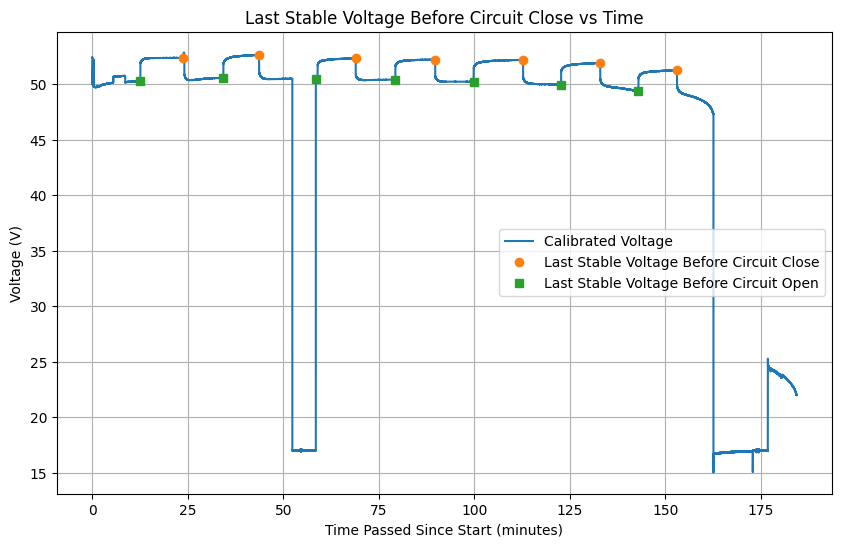

In [93]:
plt.figure(figsize=(10, 6))
plt.plot(combined_df['Translated Time (minutes)'], combined_df['Calibrated Voltage'], label='Calibrated Voltage')
plt.plot(last_stable_voltages_before_close['time'], last_stable_voltages_before_close['voltage'], 'o', label='Last Stable Voltage Before Circuit Close')
plt.plot(last_stable_voltages_before_open['time'], last_stable_voltages_before_open['voltage'], 's', label='Last Stable Voltage Before Circuit Open')
plt.xlabel('Time Passed Since Start (minutes)')
plt.ylabel('Voltage (V)')
plt.title('Last Stable Voltage Before Circuit Close vs Time')
plt.legend()
plt.grid()
plt.show()

In [69]:
is_close_filtered = False
is_open_filtered = False

In [ ]:
is_close_filtered = True
is_open_filtered = True

In [79]:
print(last_stable_voltages_before_close)
print(last_stable_voltages_before_open)

{'index': [1492630, 2671045, 4239708, 5523407, 6945422, 8190944, 9440165], 'time': [np.float64(24.10656765166666), np.float64(43.66643954999999), np.float64(68.95378443000001), np.float64(89.75069793250005), np.float64(112.76274617000001), np.float64(132.93641707333336), np.float64(153.0244092233334)], 'voltage': [np.float64(52.82729045548181), np.float64(52.635896910048075), np.float64(52.32712657358663), np.float64(52.22109370565346), np.float64(52.188561959258415), np.float64(51.905010757610434), np.float64(51.23853183794919)]}
{'index': [784146, 2092393, 3595802, 4875703, 6146751, 7556718, 8810603], 'time': [np.float64(12.60611630083333), np.float64(34.32035291666666), np.float64(58.524366486666665), np.float64(79.33039983083337), np.float64(99.81197282333336), np.float64(122.70627217333337), np.float64(142.9380094)], 'voltage': [np.float64(50.26886079194324), np.float64(50.57847489127948), np.float64(17.035338063630128), np.float64(50.39856589608606), np.float64(50.209703639276725

In [82]:
print(combined_df['Calibrated Voltage'].iloc[1480000])

52.36579903868163


In [83]:
# replace idx 0 before close 
last_stable_voltages_before_close['index'][0] = 1480000
last_stable_voltages_before_close['time'][0] = combined_df['Translated Time (minutes)'].iloc[last_stable_voltages_before_close['index'][0]]
last_stable_voltages_before_close['voltage'][0] = combined_df['Calibrated Voltage'].iloc[last_stable_voltages_before_close['index'][0]]

In [86]:
idx = 3595802
while combined_df['Calibrated Voltage'].iloc[idx] < 25:
    idx += 1
print('Found', idx, 'with voltage', combined_df['Calibrated Voltage'].iloc[idx], 'at time', combined_df['Translated Time (minutes)'].iloc[idx])

Found 3596300 with voltage 50.50108308537423 at time 58.53231191666667


In [92]:
# replace idx 0 before open 
last_stable_voltages_before_open['index'][2] = 3596300 
last_stable_voltages_before_open['time'][2] = combined_df['Translated Time (minutes)'].iloc[last_stable_voltages_before_open['index'][2]]
last_stable_voltages_before_open['voltage'][2] = combined_df['Calibrated Voltage'].iloc[last_stable_voltages_before_open['index'][2]]

In [94]:
create_csv_output_file(override=True, csv_data=combined_df)

In [95]:
outpus_json_points = {
    "before_close": {
        "index": last_stable_voltages_before_close['index'],
        "time": last_stable_voltages_before_close['time'],
        "voltage": last_stable_voltages_before_close['voltage']
    },
    "before_open": {
        "index": last_stable_voltages_before_open['index'],
        "time": last_stable_voltages_before_open['time'],
        "voltage": last_stable_voltages_before_open['voltage']
    }
}
print(f"Saved {len(last_stable_voltages_before_close['index'])} points for before close and {len(last_stable_voltages_before_open['time'])} points for before open to {points_of_interest_file_name}.")
json.dump(outpus_json_points, open(points_of_interest_file_name, 'w'), indent=4)

Saved 7 points for before close and 7 points for before open to c:\Users\Kor\Documents\GitHub\Proa-II-Electrical-Setup\Calibration Data 2\Data\Data Start Point\points_of_interest.json.
